For my submetric to try and find the best neighborhood in Pittsburgh I focused on two submetrics Income per households and rent. The data set that i found layed out a bunch of ranges of both income and rent so in order to get a better understanding I decided to weight each region based on their lower bound and then take then mutiply that by the number of recidents or people in that range. I then averaged it out by the total number of people who were surveyed. This got me both the averege rent and average income. I then compared the two of them to figure out what neighborhood had the highest income to rent ratio. 

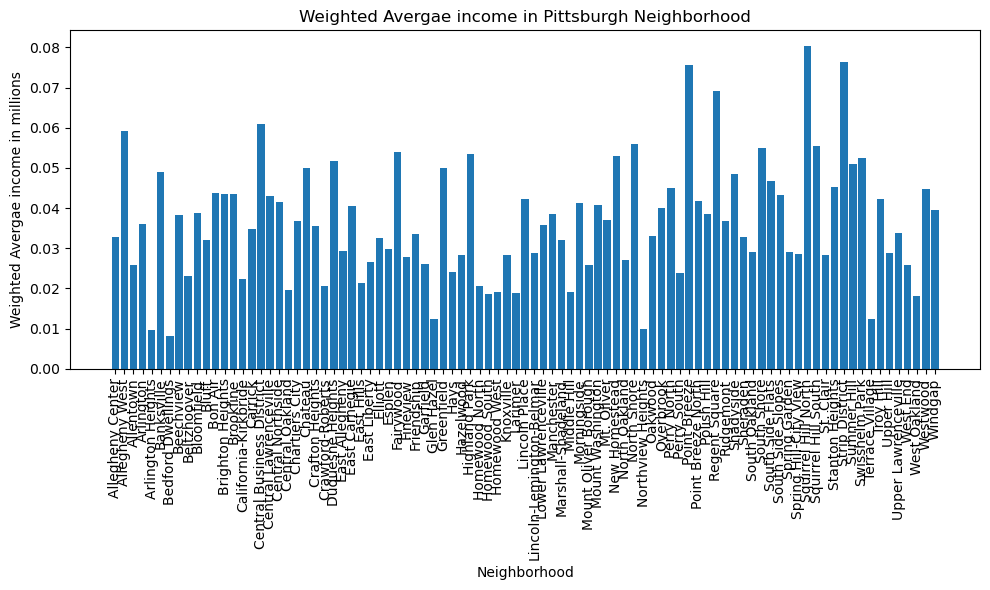

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#import CSV
income = pd.read_csv("income.csv")
headers = income.columns.tolist()
headers = headers[6:]
temp = []
x = 0
for heads in headers:
    if x % 2 == 1:
        temp.append(heads)
    x += 1
headers = temp 

neighborhood = income["Neighborhood"].tolist()
income["weightsIncome"] = 0.0
weights = [
    0.005,
    0.01,
    0.015,
    0.02,
    0.025,
    0.03,
    0.035,
    0.04,
    0.045,
    0.05,
    0.06,
    0.075,
    0.1,
    0.125,
    0.15,
    0.2
]

for j in neighborhood:
    temp = 0  # will be the temp value of weightsIncome for each row
    x = 0  # counter to index through weights 
    row = income.loc[income['Neighborhood'] == j]
    for i in headers:
        temp += (row[i] * weights[x])
        x += 1
    temp = temp/income.loc[income['Neighborhood'] == j, "Estimate; Total:"]
    income.loc[income['Neighborhood'] == j, "weightsIncome"]  = temp 

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(income["Neighborhood"], income["weightsIncome"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Weighted Avergae income in millions")
plt.title("Weighted Avergae income in Pittsburgh Neighborhood")
plt.tight_layout()
plt.show()


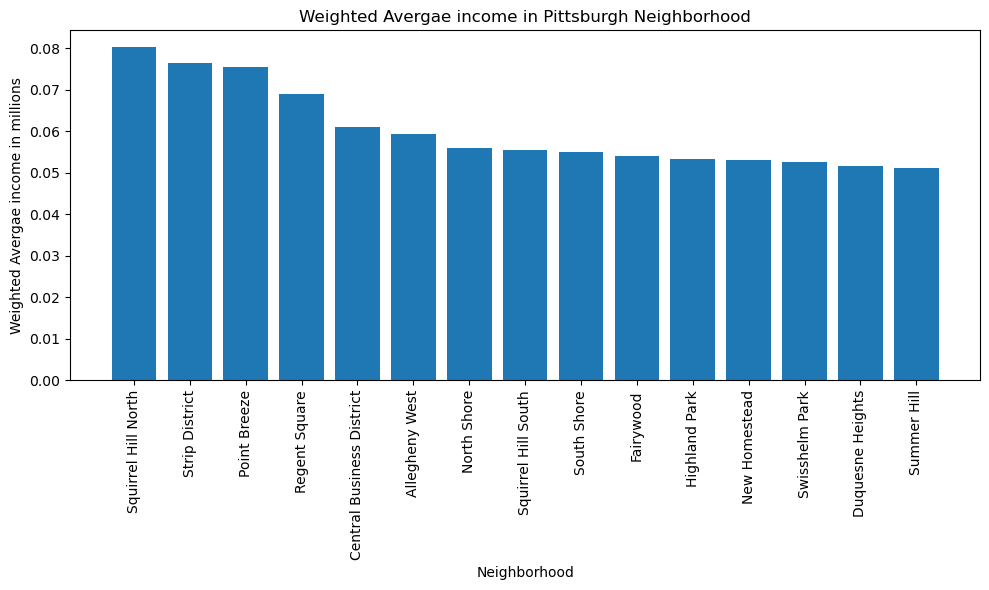

In [2]:
# Select the top 15
income = income.sort_values(by='weightsIncome', ascending=False)
incomeTop15 = income.head(15)

plt.figure(figsize=(10, 6))
plt.bar(incomeTop15["Neighborhood"], incomeTop15["weightsIncome"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Weighted Avergae income in millions")
plt.title("Weighted Avergae income in Pittsburgh Neighborhood")
plt.tight_layout()
plt.show()

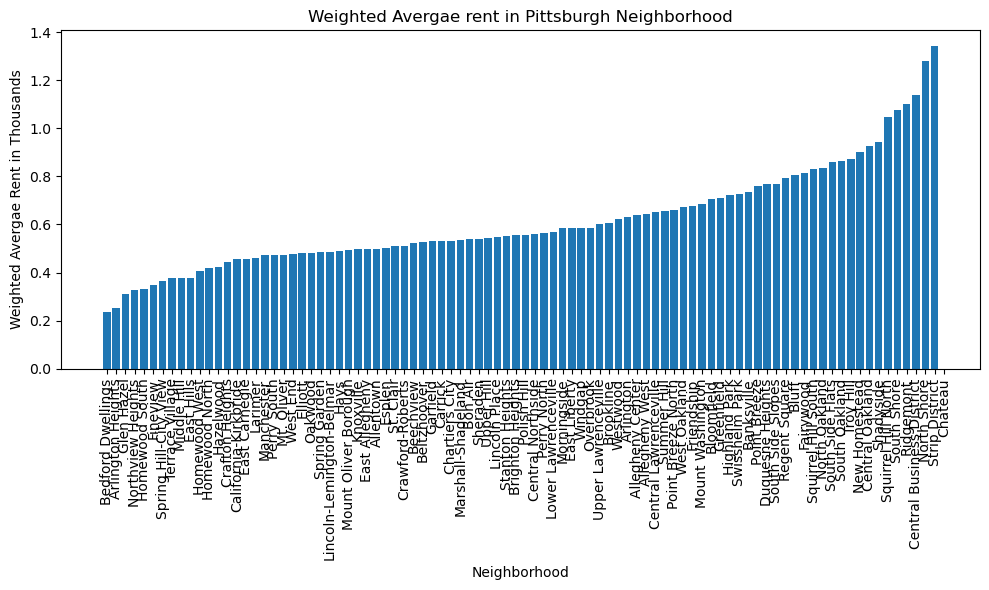

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

#import CSV
rent = pd.read_csv("rent.csv")
headers = rent.columns.tolist()
headers = headers[7:-2]
temp = []
x = 0
for heads in headers:
    if x % 2 == 0:
        temp.append(heads)
    x += 1
headers = temp 

neighborhood = rent["Neighborhood"].tolist()
rent["weightsRent"] = 0.0
weights = [
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.3,
    0.35,
    0.4,
    0.45,
    0.5,
    0.55,
    0.6,
    0.65,
    0.7,
    0.75,
    0.8,
    0.9,
    1,
    1.25,
    1.5,
    2
]

for j in neighborhood:
    temp = 0  # will be the temp value of rentIncome for each row
    x = 0  # counter to index through weights 
    row = rent.loc[income['Neighborhood'] == j]
    for i in headers:
        temp += (row[i] * weights[x])
        x += 1
    temp = temp/rent.loc[income['Neighborhood'] == j, "Estimate; With cash rent:"]
    rent.loc[rent['Neighborhood'] == j, "weightsRent"]  = temp 

rent = rent.sort_values(by='weightsRent', ascending=True)
# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(rent["Neighborhood"], rent["weightsRent"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Weighted Avergae Rent in Thousands")
plt.title("Weighted Avergae rent in Pittsburgh Neighborhood")
plt.tight_layout()
plt.show()


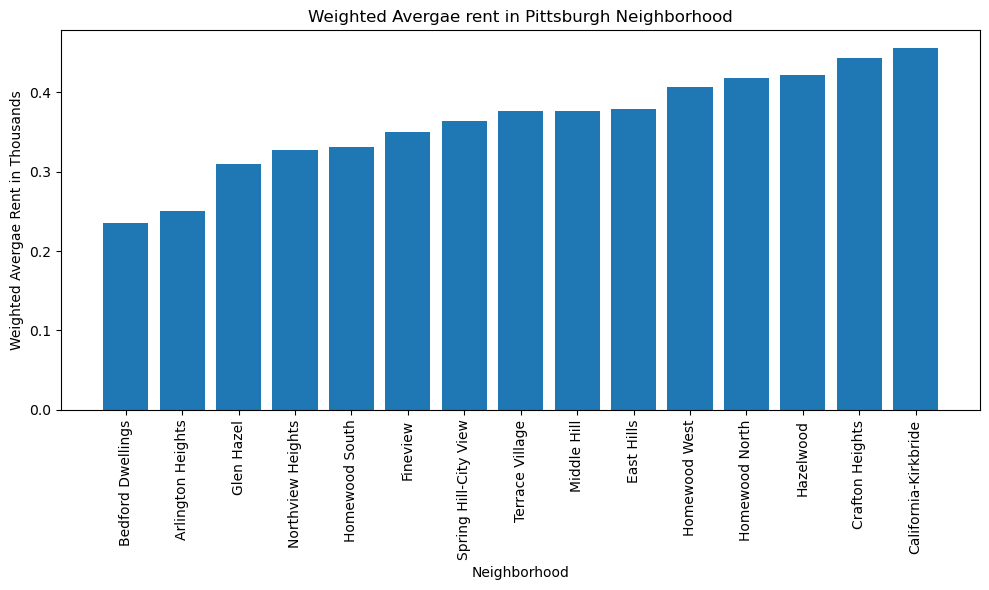

In [4]:
# Select the top 15
rent = rent.sort_values(by='weightsRent', ascending=True)
rentTop15 = rent.head(15)

plt.figure(figsize=(10, 6))
plt.bar(rentTop15["Neighborhood"], rentTop15["weightsRent"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Weighted Avergae Rent in Thousands")
plt.title("Weighted Avergae rent in Pittsburgh Neighborhood")
plt.tight_layout()
plt.show()

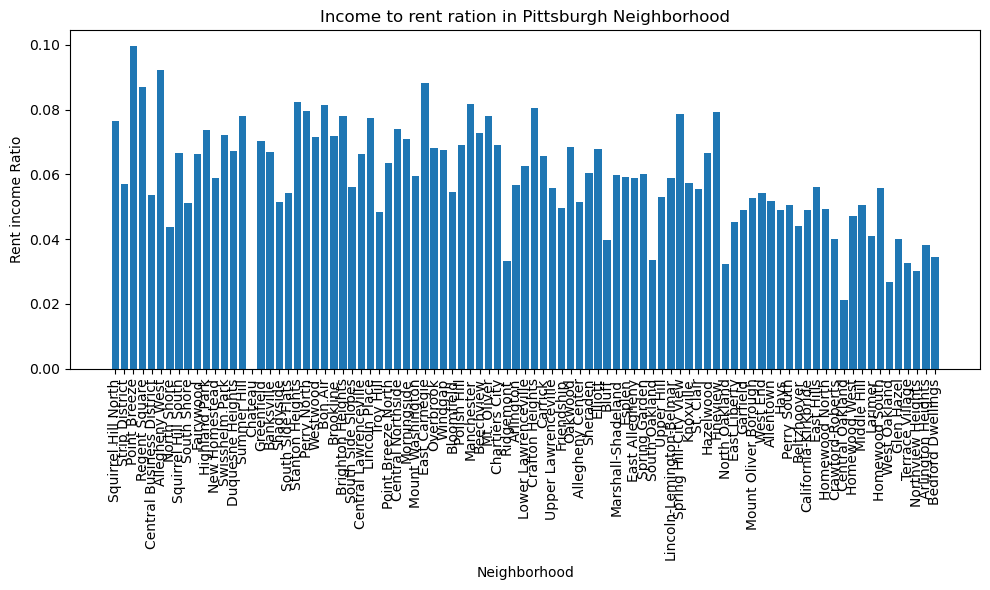

In [5]:
income["weightsRent"] = 0.0
income["rentIncomeRatio"] = 0.0
for j in neighborhood:
    income.loc[income['Neighborhood'] == j, "weightsRent"]  =  rent.loc[rent['Neighborhood'] == j, "weightsRent"]
    income.loc[income['Neighborhood'] == j, "rentIncomeRatio"] = (income.loc[income['Neighborhood'] == j, "weightsIncome"])/(rent.loc[rent['Neighborhood'] == j, "weightsRent"])
plt.figure(figsize=(10, 6))
plt.bar(income["Neighborhood"], income["rentIncomeRatio"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Rent income Ratio")
plt.title("Income to rent ration in Pittsburgh Neighborhood")
plt.tight_layout()
plt.show()

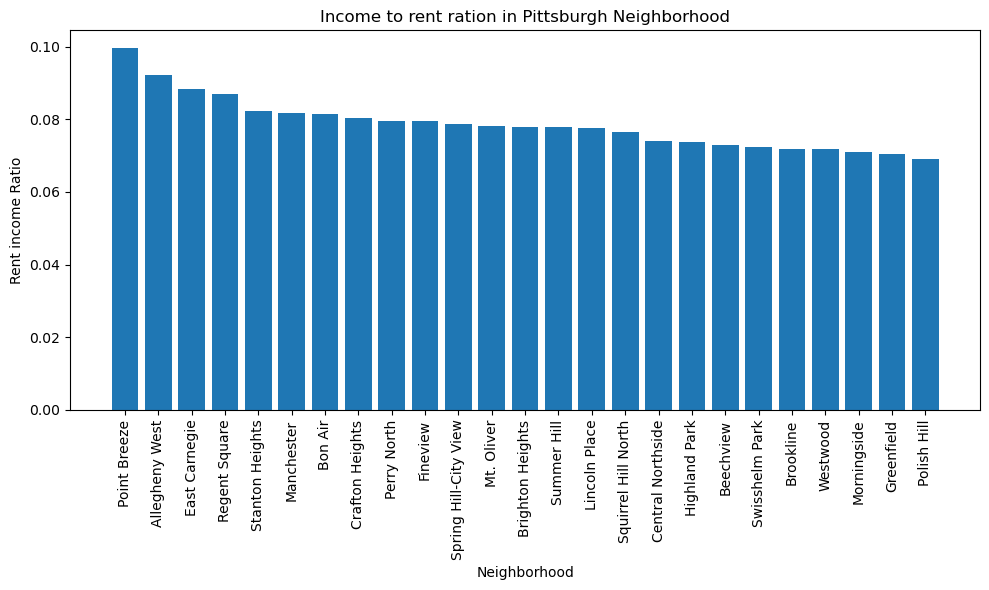

63             Point Breeze
1            Allegheny West
26            East Carnegie
66            Regent Square
79          Stanton Heights
48               Manchester
11                  Bon Air
22          Crafton Heights
61              Perry North
32                 Fineview
75    Spring Hill-City View
54               Mt. Oliver
12         Brighton Heights
81              Summer Hill
45            Lincoln Place
76      Squirrel Hill North
18        Central Northside
39            Highland Park
7                 Beechview
82           Swisshelm Park
13                Brookline
89                 Westwood
51              Morningside
36               Greenfield
65              Polish Hill
Name: Neighborhood, dtype: object


In [6]:
income = income.sort_values(by='rentIncomeRatio', ascending=False)
rentIncomeTop15 = income.head(25)

plt.figure(figsize=(10, 6))
plt.bar(rentIncomeTop15["Neighborhood"], rentIncomeTop15["rentIncomeRatio"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Rent income Ratio")
plt.title("Income to rent ration in Pittsburgh Neighborhood")
plt.tight_layout()
plt.show()
print(rentIncomeTop15["Neighborhood"])

In [7]:
income.to_csv('changedIncome.csv', index=False) 